In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

from typing import Any
from jaxtyping import PyTree

import datasets as hf_datasets
from datasets import load_dataset

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import flax.linen as nn

from jaxili.utils import create_data_loader
from jaxili.inference import NPE, NLE
from jaxili.train import TrainerModule
from jaxili.compressor import MLPCompressor
from jaxili.compressor import Compressor

from getdist import plots, MCSamples
%matplotlib inline

print("Jax device:", jax.devices())

Jax device: [CudaDevice(id=0)]


In [11]:
sim_cls = np.load("demo_compression_LFI_data_cl.npy", allow_pickle=True).item()

In [12]:
sim_cls

{'params': array([[0.20359217, 0.91916668],
        [0.19104611, 0.92219313],
        [0.17354691, 0.85684984],
        ...,
        [0.28453441, 0.87770545],
        [0.2983474 , 0.783065  ],
        [0.40438342, 0.73770215]]),
 'final_dv': array([[ 2.85133958e-08,  1.53177717e-08,  6.67527494e-09, ...,
          7.51167736e-12,  1.24910854e-10,  4.35819881e-11],
        [ 2.25966673e-08,  1.42888668e-08,  1.32744441e-08, ...,
          1.78397739e-10,  1.57262900e-10,  4.77453813e-11],
        [ 2.29174241e-08,  1.19375907e-08,  9.92478490e-09, ...,
          1.09901392e-10,  5.53496567e-11, -2.26421358e-12],
        ...,
        [ 2.05527143e-08,  1.63299767e-08,  8.92997794e-09, ...,
          1.14936150e-10,  2.44797279e-10,  5.62004830e-11],
        [ 1.75943112e-08,  5.08663625e-09,  6.01132875e-09, ...,
         -1.02797991e-11,  4.66535514e-11,  6.24662580e-11],
        [ 1.37294451e-08,  7.67380311e-09,  4.48446408e-09, ...,
          5.98240107e-12,  3.95641528e-12, -4.60485

In [13]:
sim_cls['final_dv'].shape

(8628, 200)

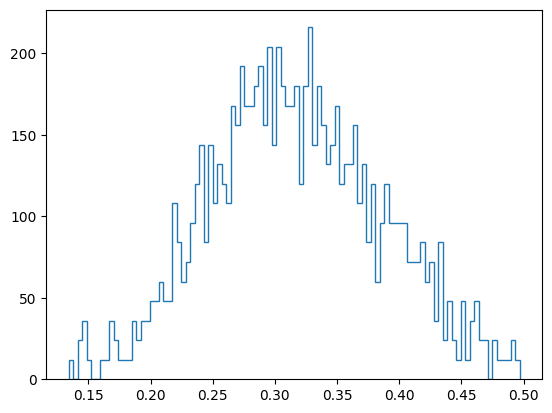

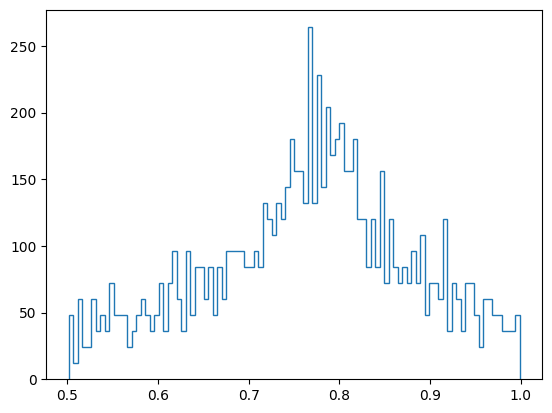

In [14]:
plt.figure()

plt.hist(sim_cls["params"][:, 0], bins=100, histtype='step')

plt.show()

plt.figure()

plt.hist(sim_cls["params"][:, 1], bins=100, histtype='step')

plt.show()

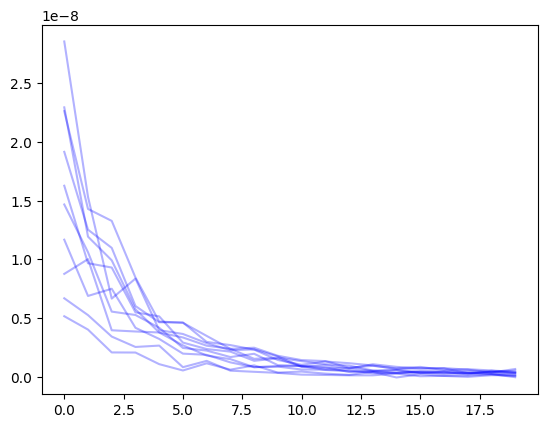

In [15]:
plt.figure()

for i in range(10):
    plt.plot(sim_cls["final_dv"][i][:20], color='blue', alpha=0.3)
plt.show()

In [20]:
sim_cls["final_dv"] = sim_cls["final_dv"][:, :20]

In [21]:
sim_cls["final_dv"].shape

(8628, 20)

### Compression with MSE

In [22]:
model_class = MLPCompressor

model_hparams = model_hparams={
    'hidden_size': [64, 64, 32],
    'activation': jax.nn.relu,
    'output_size': 2,
}

compressor = Compressor(
    model_class=model_class,
    model_hparams=model_hparams
)

mean_cls = np.mean(sim_cls['final_dv'], axis=0)
std_cls = np.std(sim_cls['final_dv'], axis=0)

normalized_cells = (sim_cls['final_dv'] - mean_cls)/std_cls

compressor = compressor.append_simulations(sim_cls['params'].astype(np.float32), normalized_cells.astype(np.float32))

[!] Inputs are valid.
[!] Appending 8628 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 6039 simulations.
[!] Validation set: 1726 simulations.
[!] Test set: 863 simulations.


In [23]:
CHECKPOINT_PATH = "."
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

metrics, MSE_compression_function = compressor.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=500,
    min_delta=1e-6
)

[!] Creating DataLoaders with batch_size 50.
[!] Building the neural network.
[!] Creating the Trainer module.

                             MLPCompressor Summary                              
┏━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module        ┃ inputs        ┃ outputs       ┃ params             ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│         │ MLPCompressor │ float32[1,20] │ float32[1,2]  │                    │
├─────────┼───────────────┼───────────────┼───────────────┼────────────────────┤
│ Dense_0 │ Dense         │ float32[1,20] │ float32[1,64] │ bias: float32[64]  │
│         │               │               │               │ kernel:            │
│         │               │               │               │ float32[20,64]     │
│         │               │               │               │                    │
│         │               │               │               │ 1,344 (5.4 KB)    

Epochs: Val loss 0.025279/ Best val loss 0.016968:  25%|██▌       | 126/500 [00:32<01:35,  3.92it/s]


Neural network training stopped after 127 epochs.
Early stopping with best validation metric: 0.016967691481113434
Best model saved at epoch 106
Early stopping parameters: min_delta=1e-06, patience=20
[!] Training loss: 0.0016627507284283638
[!] Validation loss: 0.016967691481113434
[!] Test loss: 0.003343310672789812


In [24]:
theta_test, x_test = compressor._test_dataset[:][0], compressor._test_dataset[:][1]
t_test = MSE_compression_function(x_test)

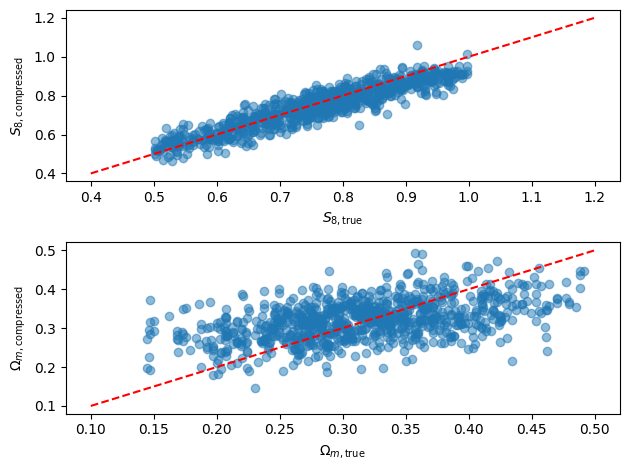

In [25]:
plt.figure()

plt.subplot(211)

plt.scatter(theta_test[:, 1], t_test[:, 1], alpha=0.5)
plt.plot([0.4, 1.2], [0.4, 1.2], linestyle='--', color='red')
plt.xlabel(r'$S_{8, \rm true}$')
plt.ylabel(r'$S_{8, \rm compressed}$')


plt.subplot(212)

plt.scatter(theta_test[:, 0], t_test[:, 0], alpha=0.5)
plt.plot([0.1, 0.5], [0.1, 0.5], linestyle='--', color='red')
plt.xlabel(r'$\Omega_{m, \rm true}$')
plt.ylabel(r'$\Omega_{m, \rm compressed}$')


plt.tight_layout()

plt.savefig("compression_output_des.png", dpi=600)
plt.show()

In [26]:
compressed_dv = MSE_compression_function(normalized_cells)

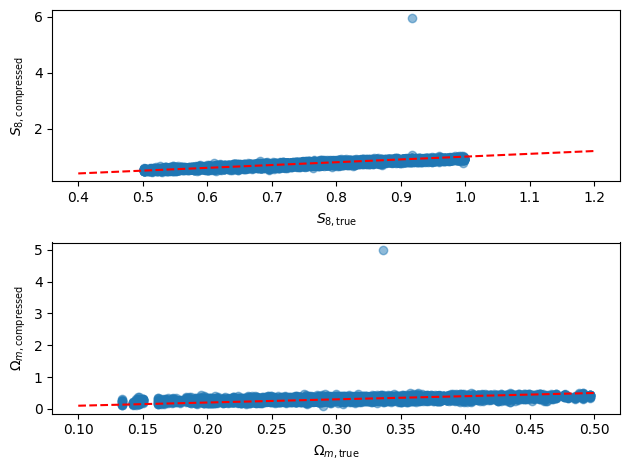

In [27]:
plt.figure()

plt.subplot(211)

plt.scatter(sim_cls["params"][:, 1], compressed_dv[:, 1], alpha=0.5)
plt.plot([0.4, 1.2], [0.4, 1.2], linestyle='--', color='red')
plt.xlabel(r'$S_{8, \rm true}$')
plt.ylabel(r'$S_{8, \rm compressed}$')


plt.subplot(212)

plt.scatter(sim_cls["params"][:, 0], compressed_dv[:, 0], alpha=0.5)
plt.plot([0.1, 0.5], [0.1, 0.5], linestyle='--', color='red')
plt.xlabel(r'$\Omega_{m, \rm true}$')
plt.ylabel(r'$\Omega_{m, \rm compressed}$')


plt.tight_layout()

plt.savefig("compression_output_des.png", dpi=600)
plt.show()

In [28]:
mask = ~(compressed_dv[:, 0] > 4.0)

[[0.33606797 0.91736888]]


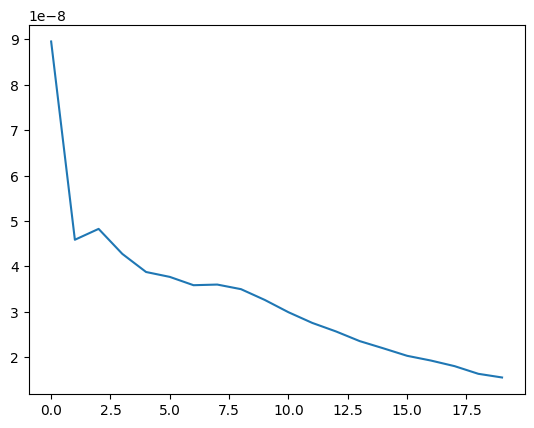

In [29]:
plt.figure()

plt.plot(sim_cls["final_dv"][~mask][0])

print(sim_cls["params"][~mask])

plt.show()

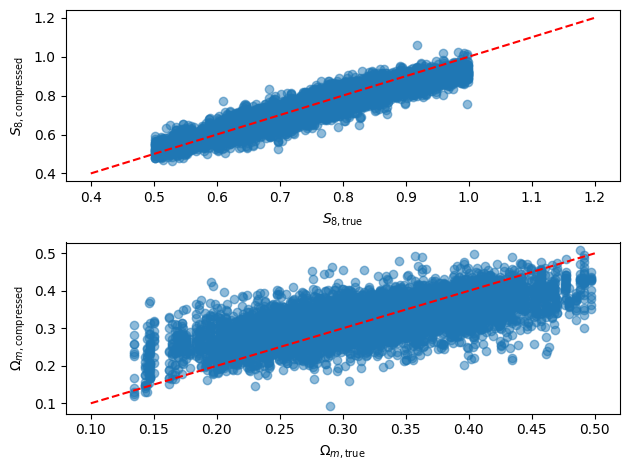

In [30]:
plt.figure()

plt.subplot(211)

plt.scatter(sim_cls["params"][:, 1][mask], compressed_dv[:, 1][mask], alpha=0.5)
plt.plot([0.4, 1.2], [0.4, 1.2], linestyle='--', color='red')
plt.xlabel(r'$S_{8, \rm true}$')
plt.ylabel(r'$S_{8, \rm compressed}$')


plt.subplot(212)

plt.scatter(sim_cls["params"][:, 0][mask], compressed_dv[:, 0][mask], alpha=0.5)
plt.plot([0.1, 0.5], [0.1, 0.5], linestyle='--', color='red')
plt.xlabel(r'$\Omega_{m, \rm true}$')
plt.ylabel(r'$\Omega_{m, \rm compressed}$')


plt.tight_layout()

#plt.savefig("compression_output_des.png", dpi=600)
plt.show()

In [31]:
truths = sim_cls["params"][mask][:10]
observations = sim_cls["final_dv"][mask][:10]
compressed_observations = compressed_dv[mask][:10]

### Performing inference (NPE)

In [32]:
inference_npe = NPE()

In [33]:
inference_npe = inference_npe.append_simulations(sim_cls["params"].astype(np.float32)[mask], compressed_dv[mask])

[!] Inputs are valid.
[!] Appending 8627 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 6038 simulations.
[!] Validation set: 1726 simulations.
[!] Test set: 863 simulations.


In [34]:
#Let's train the normalizing flow

#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./PS_inference"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 500
learning_rate=1e-4

metrics, density_estimator = inference_npe.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=learning_rate
)

[!] Creating DataLoaders with batch_size 50.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -3.4247/ Best val loss -3.4253:  16%|█▌        | 80/500 [00:34<03:01,  2.31it/s]


Neural network training stopped after 81 epochs.
Early stopping with best validation metric: -3.425302743911743
Best model saved at epoch 60
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -3.4041926860809326
[!] Validation loss: -3.425302743911743
[!] Test loss: -3.4196617603302


The loss explodes because of the one or two points that did not compress correctly leading to some kind of singularity. Masking them helps to avoid this explosion of the loss.

In [35]:
posterior_npe = inference_npe.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


In [36]:
truth, observation =  truths[4], compressed_observations[4]
print("True cosmology:", truth)

True cosmology: [0.30883259 0.76604453]


In [37]:
#Let's sample
num_samples = 10_000
random_key = jax.random.PRNGKey(0)
samples_npe = posterior_npe.sample(
    x=observation, num_samples=num_samples, key=random_key
)

Removed no burn in
Removed no burn in


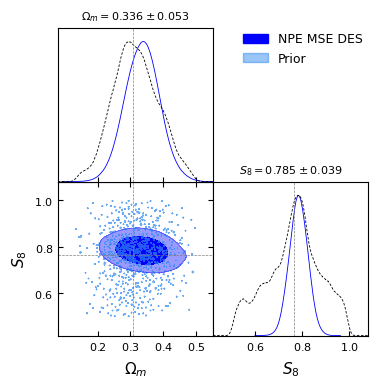

In [46]:
labels = ['\Omega_m', 'S_8']

samples_gd_npe = MCSamples(samples=samples_npe, names=labels, labels=labels)
samples_gd_prior = MCSamples(samples=sim_cls["params"].astype(np.float32), names=labels, labels=labels)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_npe, samples_gd_prior], filled=True,
                line_args=[
                    {'color': 'blue'},
                    {'color': 'black',
                     'ls': '--'}
                ],
                contour_colors=['blue', None],
                markers={
                    label: val for label, val in zip(labels, truth)
                },
                legend_labels=['NPE MSE DES', 'Prior'],
               title_limit=1)

plt.savefig("pseudo_cell_constraint_npe_DES_one_bin.png", dpi=600)
plt.show()

### Inference with NLE

In [39]:
inference_nle = NLE()

In [40]:
inference_nle = inference_nle.append_simulations(sim_cls["params"].astype(np.float32)[mask], compressed_dv[mask])

[!] Inputs are valid.
[!] Appending 8627 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 6038 simulations.
[!] Validation set: 1726 simulations.
[!] Test set: 863 simulations.


In [41]:
#Let's train the normalizing flow

#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./PS_inference"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 500
learning_rate=1e-4

metrics, density_estimator = inference_nle.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=learning_rate
)

[!] Creating DataLoaders with batch_size 50.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -3.8711/ Best val loss -3.8709:  19%|█▉        | 95/500 [00:39<02:48,  2.40it/s]


Neural network training stopped after 96 epochs.
Early stopping with best validation metric: -3.870896577835083
Best model saved at epoch 95
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -3.835160970687866
[!] Validation loss: -3.871107816696167
[!] Test loss: -3.7906713485717773


In [42]:
import numpyro.distributions as dist

posterior_nle = inference_nle.build_posterior(
    prior_distr=dist.Uniform(low=jnp.array([0.15, 0.5]), high=jnp.array([0.52, 1.0]))
)

Using MCMC method: nuts_numpyro
MCMC kwargs: {}
[!] Posterior $p(\theta| x)$ built. The class MCMCPosterior is used to sample and evaluate the log probability.\n The sampling is performed using MCMC methods.


In [43]:
#Let's sample
num_samples = 10_000
random_key = jax.random.PRNGKey(0)
samples_nle = posterior_nle.sample(
    x=observation.reshape((1, -1)), num_samples=num_samples, key=random_key
)

Removed no burn in


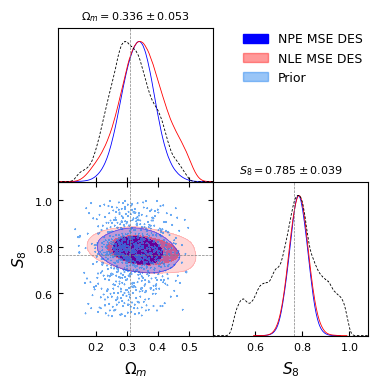

In [44]:
samples_gd_nle = MCSamples(samples=samples_nle, names=labels, labels=labels)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_npe, samples_gd_nle, samples_gd_prior], filled=True,
                line_args=[
                    {'color': 'blue'},
                    {'color': 'red'},
                    {'color': 'black',
                     'ls': '--'}
                ],
                contour_colors=['blue', 'red', None],
                markers={
                    label: val for label, val in zip(labels, truth)
                },
                legend_labels=['NPE MSE DES', 'NLE MSE DES', 'Prior'],
               title_limit=1)

plt.savefig("pseudo_cell_constraint_nle_DES_one_bin.png", dpi=600)
plt.show()

## Using VMIM compression

In [47]:
#To perform the compression, we first need to perform an NPE with an embedding net
compression_vmim = NPE()

In [48]:
compression_vmim = compression_vmim.append_simulations(sim_cls['params'].astype(np.float32)[mask], sim_cls["final_dv"].astype(np.float32)[mask])

[!] Inputs are valid.
[!] Appending 8627 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 6038 simulations.
[!] Validation set: 1726 simulations.
[!] Test set: 863 simulations.


In [49]:
#Let's train the normalizing flow

#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./PS_compression"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 500

batch_size = 50

compressor_hparams = {
    'activation': jax.nn.relu,
    'output_size': 2
}


metrics, density_estimator = compression_vmim.train(
    training_batch_size=batch_size,
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    embedding_net=model_class, #MLPCompressor
    embedding_hparams=model_hparams
)

[!] Creating DataLoaders with batch_size 50.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -3.2036/ Best val loss -3.2465:   8%|▊         | 38/500 [00:19<03:59,  1.93it/s]


Neural network training stopped after 39 epochs.
Early stopping with best validation metric: -3.2464962005615234
Best model saved at epoch 18
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -3.2608749866485596
[!] Validation loss: -3.2464962005615234
[!] Test loss: -3.2876851558685303


In [50]:
posterior_vmim = compression_vmim.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


In [51]:
observation, truth = compression_vmim._test_dataset[1][1], compression_vmim._test_dataset[1][0]
print("True cosmology:", truth)

True cosmology: [0.3570371  0.73674136]


In [54]:
#Let's sample
num_samples = 10_000
random_key = jax.random.PRNGKey(0)
samples_vmim_comp = posterior_vmim.sample(
    x=observation, num_samples=num_samples, key=random_key
)

Removed no burn in


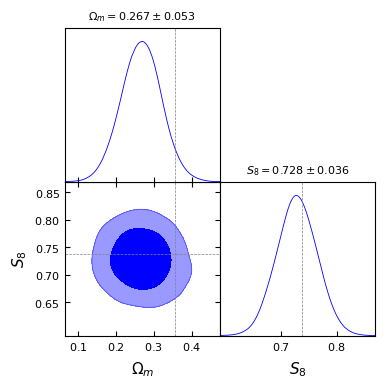

In [55]:
#and let's finally plot the result
labels = ['\Omega_m', 'S_8']

samples_gd_vmim_comp = MCSamples(samples=samples_vmim_comp, names=labels, labels=labels)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_vmim_comp], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, truth)
                },
               title_limit=1)

plt.show()

In [96]:
compressor = compression_vmim.trainer.bind_model()
compressed_dv_vmim = compressor.embedding(sim_cls["final_dv"][mask])

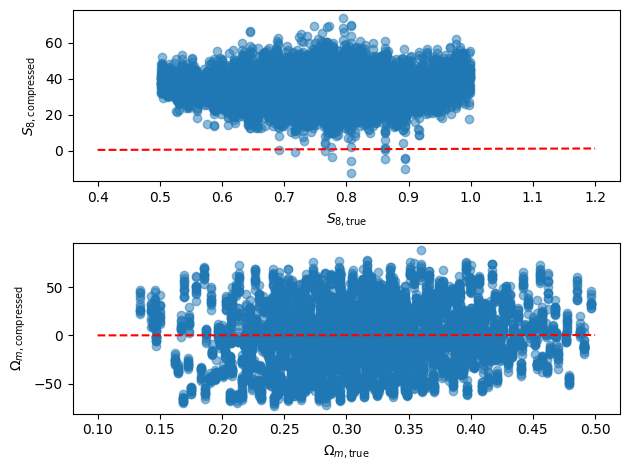

In [97]:
plt.figure()

plt.subplot(211)

plt.scatter(sim_cls["params"][:, 1][mask], compressed_dv_vmim[:, 1], alpha=0.5)
plt.plot([0.4, 1.2], [0.4, 1.2], linestyle='--', color='red')
plt.xlabel(r'$S_{8, \rm true}$')
plt.ylabel(r'$S_{8, \rm compressed}$')


plt.subplot(212)

plt.scatter(sim_cls["params"][:, 0][mask], compressed_dv_vmim[:, 0], alpha=0.5)
plt.plot([0.1, 0.5], [0.1, 0.5], linestyle='--', color='red')
plt.xlabel(r'$\Omega_{m, \rm true}$')
plt.ylabel(r'$\Omega_{m, \rm compressed}$')


plt.tight_layout()

plt.savefig("compression_output_des_vmim.png", dpi=600)
plt.show()

### NPE with VMIM compression

In [98]:
inference_npe_VMIM = NPE()

In [100]:
inference_npe_VMIM = inference_npe_VMIM.append_simulations(sim_cls["params"].astype(np.float32)[mask], compressed_dv_vmim)

[!] Inputs are valid.
[!] Appending 8627 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 6038 simulations.
[!] Validation set: 1726 simulations.
[!] Test set: 863 simulations.


In [101]:
#Let's train the normalizing flow

#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./PS_inference"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 500
learning_rate=1e-4

metrics, density_estimator = inference_npe_VMIM.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=learning_rate
)

[!] Creating DataLoaders with batch_size 50.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -4.0965/ Best val loss -4.0965:  19%|█▉        | 97/500 [00:37<02:34,  2.61it/s]


Neural network training stopped after 98 epochs.
Early stopping with best validation metric: -4.096539497375488
Best model saved at epoch 79
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -4.106564521789551
[!] Validation loss: -4.097049236297607
[!] Test loss: -4.084362030029297


In [103]:
posterior_npe_VMIM = inference_npe_VMIM.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


In [129]:
#Let's sample
num_samples = 10_000
random_key = jax.random.PRNGKey(0)
samples_npe_vmim = posterior_npe_VMIM.sample(
    x=compressed_dv_vmim[4], num_samples=num_samples, key=random_key
)

In [130]:
#Let's sample
num_samples = 10_000
random_key = jax.random.PRNGKey(0)
samples_npe_vmim_compressor = posterior_vmim.sample(
    x=observations[4], num_samples=num_samples, key=random_key
)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


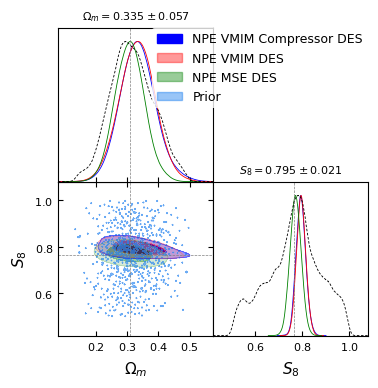

In [131]:
labels = ['\Omega_m', 'S_8']

samples_gd_npe = MCSamples(samples=samples_npe, names=labels, labels=labels)
samples_gd_npe_vmim = MCSamples(samples=samples_npe_vmim, names=labels, labels=labels)
samples_gd_npe_vmim_compressor = MCSamples(samples=samples_npe_vmim_compressor, names=labels, labels=labels)
samples_gd_prior = MCSamples(samples=sim_cls["params"].astype(np.float32), names=labels, labels=labels)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_npe_vmim_compressor, samples_gd_npe_vmim, samples_gd_npe, samples_gd_prior], filled=True,
                line_args=[
                    {'color': 'blue'},
                    {'color': 'red'},
                    {'color': 'green'},
                    {'color': 'black',
                     'ls': '--'}
                ],
                contour_colors=['blue', 'red', 'green', None],
                markers={
                    label: val for label, val in zip(labels, truth)
                },
                legend_labels=['NPE VMIM Compressor DES', 'NPE VMIM DES', 'NPE MSE DES','Prior'],
               title_limit=1)

plt.savefig("pseudo_cell_constraint_npe_vmim_DES.png", dpi=600)
plt.show()

There is a slight bias when using VMIM.. This could be due to a bad training of VMIM or just to bad luck if this point was not optimised on by the NN when training.

### Inference with NLE and VMIM

In [123]:
inference_nle_VMIM = NLE()

In [124]:
inference_nle_VMIM = inference_nle_VMIM.append_simulations(sim_cls["params"].astype(np.float32)[mask], compressed_dv_vmim)

[!] Inputs are valid.
[!] Appending 8627 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 6038 simulations.
[!] Validation set: 1726 simulations.
[!] Test set: 863 simulations.


In [125]:
#Let's train the normalizing flow

#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./PS_inference"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 500
learning_rate=1e-4

metrics, density_estimator = inference_nle_VMIM.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=learning_rate
)

[!] Creating DataLoaders with batch_size 50.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss 6.2917/ Best val loss 6.2915:  21%|██        | 106/500 [00:46<02:53,  2.27it/s]


Neural network training stopped after 107 epochs.
Early stopping with best validation metric: 6.291507720947266
Best model saved at epoch 99
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: 6.305845260620117
[!] Validation loss: 6.290596961975098
[!] Test loss: 6.27372932434082


In [127]:
posterior_nle_vmim = inference_nle_VMIM.build_posterior(
    prior_distr=dist.Uniform(low=jnp.array([0.15, 0.5]), high=jnp.array([0.52, 1.0]))
)

Using MCMC method: nuts_numpyro
MCMC kwargs: {'progress_bar': False}
[!] Posterior $p(\theta| x)$ built. The class MCMCPosterior is used to sample and evaluate the log probability.\n The sampling is performed using MCMC methods.


In [133]:
#Let's sample
num_samples = 10_000
random_key = jax.random.PRNGKey(0)
samples_nle_vmim = posterior_nle_vmim.sample(
    x=compressed_dv_vmim[4].reshape((1, -1)), num_samples=num_samples, key=random_key
)

Removed no burn in
Removed no burn in


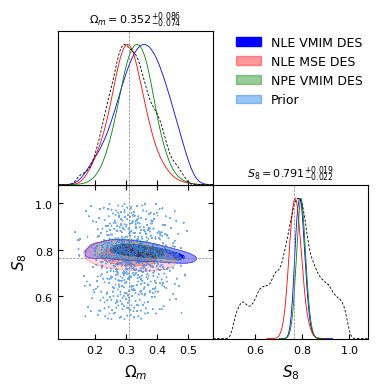

In [135]:
samples_gd_nle = MCSamples(samples=samples_nle, names=labels, labels=labels)
samples_gd_nle_vmim = MCSamples(samples=samples_nle_vmim, names=labels, labels=labels)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_nle_vmim, samples_gd_nle, samples_gd_npe_vmim, samples_gd_prior], filled=True,
                line_args=[
                    {'color': 'blue'},
                    {'color': 'red'},
                    {'color': 'green'},
                    {'color': 'black',
                     'ls': '--'}
                ],
                contour_colors=['blue', 'red', 'green', None],
                markers={
                    label: val for label, val in zip(labels, truth)
                },
                legend_labels=['NLE VMIM DES', 'NLE MSE DES', 'NPE VMIM DES', 'Prior'],
               title_limit=1)

plt.savefig("pseudo_cell_constraint_nle_vmim_DES.png", dpi=600)
plt.show()